IMPORT LIBRARIES

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay,classification_report
from matplotlib.colors import ListedColormap
import pandas as pd

DATA PREPROCESSING

In [6]:
data = pd.read_csv("/home/apiiit123/beginner_datasets/iris.csv")
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
data.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [9]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [11]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
numerical = data.select_dtypes(["int","float"]).columns
categorical = data.select_dtypes(["object","category"]).columns

CONVERTING CATEGORICAL TO NUMERICAL COLUMNS

In [13]:
label = LabelEncoder()
data["species"] = label.fit_transform(data["species"])

SEGREGATING THE DATA

In [14]:
y = data['species']          # target column
X = data.drop('species', axis=1)  # all other columns are features

SCALING THE FEATURE VARIABLES

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

SPLITTING THE DATA

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

MODEL TRAINING(SETTING NO OF CLUSTERS(K) = 5)

In [17]:
k = 5 
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier()

PREDICTING THE MODEL

In [18]:
y_pred = knn.predict(X_test)

EVALUATING THE MODEL

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"K={k} --> Accuracy: {accuracy:.2f}")

K=5 --> Accuracy: 0.93


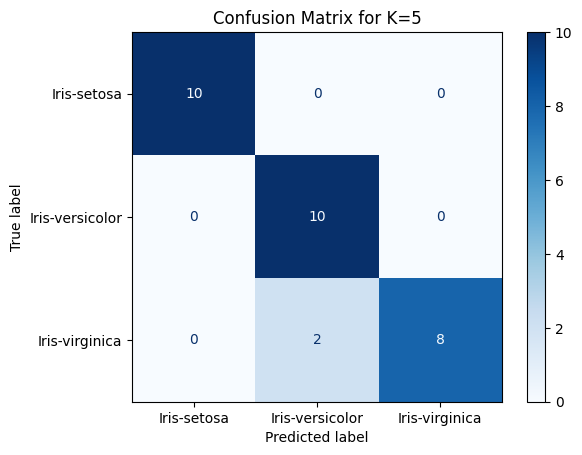

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix for K={k}")
plt.show()

In [21]:
 # Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label.classes_))


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [26]:
X_train_vis = X_train[:, :2]  # sepal_length, sepal_width
X_test_vis = X_test[:, :2]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


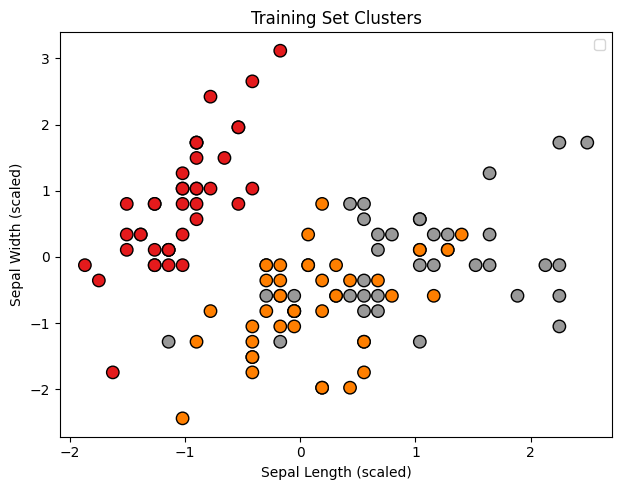

In [44]:
# Plot training data clusters
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolor='k', s=80)
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.title('Training Set Clusters')
plt.tight_layout()
plt.legend()
plt.show()

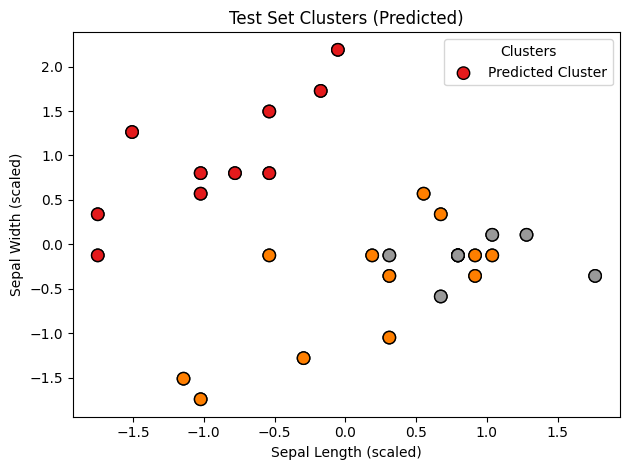

In [41]:
# Plot test data with predicted clusters
scatter = plt.scatter(X_test_vis[:, 0], X_test_vis[:, 1], c=y_pred, cmap=plt.cm.Set1, edgecolor='k', s=80,label="Predicted Cluster")
plt.subplot(1,1,1)
plt.scatter(X_test_vis[:, 0], X_test_vis[:, 1], c=y_pred, cmap=plt.cm.Set1, edgecolor='k', s=80)
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.title('Test Set Clusters (Predicted)')
plt.tight_layout()
plt.legend(handles=[scatter], title="Clusters")
plt.show()

<Figure size 640x480 with 0 Axes>